### List vs Numpy Benchmark

In [1]:
import random
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
size = 100_000

In [3]:
%timeit -n 100 -r 7 [random.random() for x in range(size)] 

4.14 ms ± 167 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [4]:
%timeit -n 100 -r 7 np.random.random(size)


348 μs ± 11.2 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [5]:
speedUp = 3.94 / 0.360

In [6]:
speedUp

10.944444444444445

In [7]:
benchmark_dict = {
    "size" : [1000, 2000, 4000],
    "cpu_time": [0.001076, 0.010615, 0.071677],
    "mps_time": [0.002471, 0.005642, 0.031364],
    "speedup": [0.44, 1.88, 2.29]
}

df = pd.DataFrame(data = benchmark_dict)

In [8]:
df

,size,cpu_time,mps_time,speedup
0,1000,0.001076,0.002471,0.44
1,2000,0.010615,0.005642,1.88
2,4000,0.071677,0.031364,2.29


In [9]:
df.to_csv("benchmark_results.csv", index=False)



In [10]:
loaded_df = pd.read_csv("benchmark_results.csv")

In [11]:
loaded_df

,size,cpu_time,mps_time,speedup
0,1000,0.001076,0.002471,0.44
1,2000,0.010615,0.005642,1.88
2,4000,0.071677,0.031364,2.29


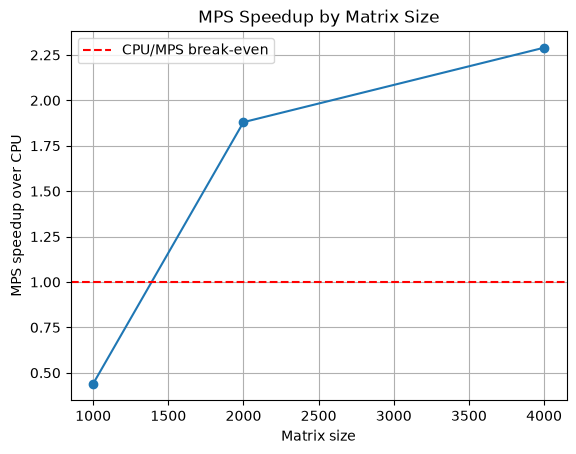

In [12]:
x = loaded_df["size"]
y = loaded_df["speedup"]

plt.plot(x, y, marker = 'o')
plt.axhline(y=1, color="red", linestyle="--", label="CPU/MPS break-even")
plt.xlabel("Matrix size")
plt.ylabel("MPS speedup over CPU")
plt.title("MPS Speedup by Matrix Size")
plt.grid(True)
plt.legend()
plt.show()